In [ ]:
# ==============================
# 1. Install library yang diperlukan
# ==============================
!pip install nltk
!pip install gensim
!pip install Sastrawi

In [ ]:
# ==============================
# 2. IMPORT LIBRARY
# ==============================
import nltk
import string
from collections import Counter
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [45]:
# ==============================
# 1. IMPORT DATA (.txt)
# ==============================

file_path = "/content/Podcast Timothy Ronald dan Dr. Tirta.txt"

with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()

print("Contoh teks awal:\n")
print(text[:500])

Contoh teks awal:

﻿oke Doter Tirta ini banyak banget yang request banyak banget request aduh ini deg-degan ya ke sini banget coy gede coy gede gede gede banget dan enggak kira di tempat segede ini isinya cuma satu orang ya waduh kadang satu kadang bisa rame-rame lah oh ya gitu ya eh tapi benar nih asli plotwist k pikir kau tuh pendek oh tadi pasu di depan kaget loh begitu ketemu halo T cerita anjir gede banget coy aslinya tetap 186 ya 181 18 181 gede coy asli gedegede gede kalau itu banyak yang bilang gitu loh ba


In [46]:
# ==============================
# 2. PREPROCESSING
# ==============================

import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 🔹 Token awal (sebelum preprocessing)
tokens_before = word_tokenize(text)
print("Jumlah token SEBELUM preprocessing:", len(tokens_before))

# 🔹 2.1 Case Folding
text = text.lower()

# 🔹 2.2 Remove punctuation & simbol
text = text.translate(str.maketrans('', '', string.punctuation))

# 🔹 2.3 Tokenization
tokens = word_tokenize(text)

# 🔹 2.4 Stopwords Bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# 🔹 2.5 Filler words
filler_words = set([
    "uh", "um", "eh", "hmm", "anu", "kayak", "jadi", "gitu",
    "kan", "ya", "nih", "sih", "dong", "deh", "kok",
    "gue", "gua", "aku", "kamu", "kita", "mereka",
    "iya", "yaudah", "oke", "ok", "nah", "loh",
    "i", "ai", "pakai", "salah", "suka", "udah",
    "aja", "gini", "bilang", "pentil", "beneran", "kaya",
    "cuman", "tuh", "oh", "lu", "banget", "ee", 'dok', 'kali', 'pas', 'bikin', 'habis',
    'situ', 'kayaknya', 'pengin', 'mas','gede', 'real', 'temanteman',
    'ivan'
])

# 🔹 2.6 Cleaning
clean_tokens = [
    word for word in tokens
    if word not in stop_words
    and word not in filler_words
    and word.isalpha()
]

print("Jumlah token setelah CLEANING:", len(clean_tokens))

# ==============================
# 🔹 2.7 STEMMING (TAMBAHAN)
# ==============================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stemmed_tokens = [stemmer.stem(word) for word in clean_tokens]

print("Contoh sebelum stemming:", clean_tokens[:10])
print("Contoh setelah stemming:", stemmed_tokens[:10])

# ==============================
# 🔹 2.8 Filtering kata jarang
# ==============================

word_freq = Counter(stemmed_tokens)

filtered_tokens = [
    word for word in stemmed_tokens
    if word_freq[word] >= 2
]

print("Jumlah token setelah FILTERING:", len(filtered_tokens))

# ==============================
# HASIL AKHIR PREPROCESSING
# ==============================

clean_text = " ".join(filtered_tokens)

print("\nContoh hasil akhir:\n")
print(clean_text[:500])

Jumlah token SEBELUM preprocessing: 18015
Jumlah token setelah CLEANING: 5990
Contoh sebelum stemming: ['doter', 'tirta', 'request', 'request', 'aduh', 'degdegan', 'coy', 'coy', 'segede', 'isinya']
Contoh setelah stemming: ['doter', 'tirta', 'request', 'request', 'aduh', 'degdegan', 'coy', 'coy', 'gede', 'isi']
Jumlah token setelah FILTERING: 4859

Contoh hasil akhir:

tirta request request aduh coy coy gede isi orang kadang kadang asli k pikir kau pendek kaget ketemu t cerita anjir coy asli coy asli ketemu banding kamera kurus takut saldo beda aku unik jarang bintang podcast podcastin orang podcastin orang benarbenar tarik bang investasi podcast nyampai nyampai orang jarang tarik orang susu tarik sempat heeh thank you ken ngulik dokter sejarah dagang podcast susah makan bagi dagang dagang penasaran sisi bisnis j fakta langsung straight to the point bisnis umu


In [47]:
# ==============================
# 5. PEMBENTUKAN PSEUDO-DOCUMENTS
# ==============================

# gunakan hasil preprocessing
words = filtered_tokens

# 🔹 parameter chunk (bisa kamu ubah)
chunk_size = 100   # 80–120 ideal

# 🔹 splitting
documents = [
    words[i:i + chunk_size]
    for i in range(0, len(words), chunk_size)
]

# 🔹 hapus dokumen terlalu pendek (<20 kata)
documents = [doc for doc in documents if len(doc) >= 20]

# ==============================
# HASIL PSEUDO-DOCUMENTS
# ==============================

print("Jumlah pseudo-documents:", len(documents))

print("\nContoh dokumen pertama:")
print(documents[0][:30])  # tampilkan 30 kata pertama

# ==============================
# Validasi HASIL PSEUDO-DOCUMENTS
# ==============================

lengths = [len(doc) for doc in documents]

print("Rata-rata panjang dokumen:", sum(lengths)/len(lengths))
print("Min:", min(lengths), "| Max:", max(lengths))

Jumlah pseudo-documents: 49

Contoh dokumen pertama:
['tirta', 'request', 'request', 'aduh', 'coy', 'coy', 'gede', 'isi', 'orang', 'kadang', 'kadang', 'asli', 'k', 'pikir', 'kau', 'pendek', 'kaget', 'ketemu', 't', 'cerita', 'anjir', 'coy', 'asli', 'coy', 'asli', 'ketemu', 'banding', 'kamera', 'kurus', 'takut']
Rata-rata panjang dokumen: 99.16326530612245
Min: 59 | Max: 100


Jumlah kata unik: 887
Jumlah kata setelah filtering: 396

Contoh BoW dokumen pertama (ID, freq):
[(0, 1), (1, 1), (2, 3), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2), (8, 1), (9, 4), (10, 3), (11, 2), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 2), (18, 1), (19, 2), (20, 1), (21, 2), (22, 1), (23, 2), (24, 1), (25, 2), (26, 1), (27, 1), (28, 3), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 3), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1)]

Versi dengan kata asli:
aduh : 1
anjir : 1
asli : 3
bagi : 1
bang : 1
benarbenar : 1
bintang : 1
bisnis : 2
cerita : 1
coy : 4
dagang : 3
ego : 2
fakta : 1
gede : 1
heeh : 1
investasi : 1
isi : 1
jarang : 2
k : 1
kadang : 2
kau : 1
ketemu : 2
langsung : 1
masuk : 2
ngerasa : 1
nyampai : 2
penasaran : 1
pikir : 1
podcast : 3
sejarah : 1
sma : 1
straight : 1
susah : 1
t : 1
takut : 1
tarik : 3
teng : 1
the : 1
tinggi : 1
tirta : 1
to : 1
umur : 1
unik : 1
usia : 1


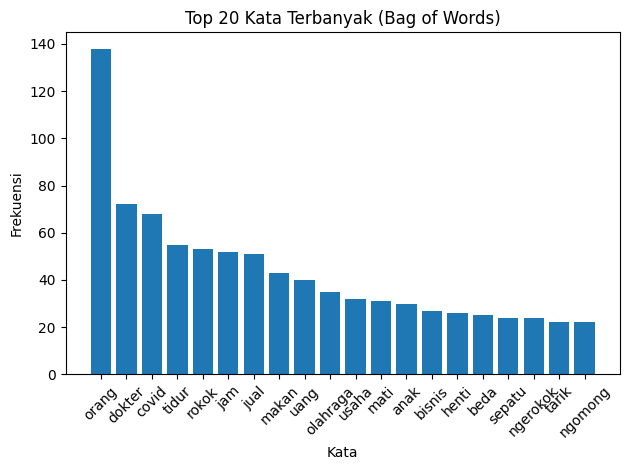

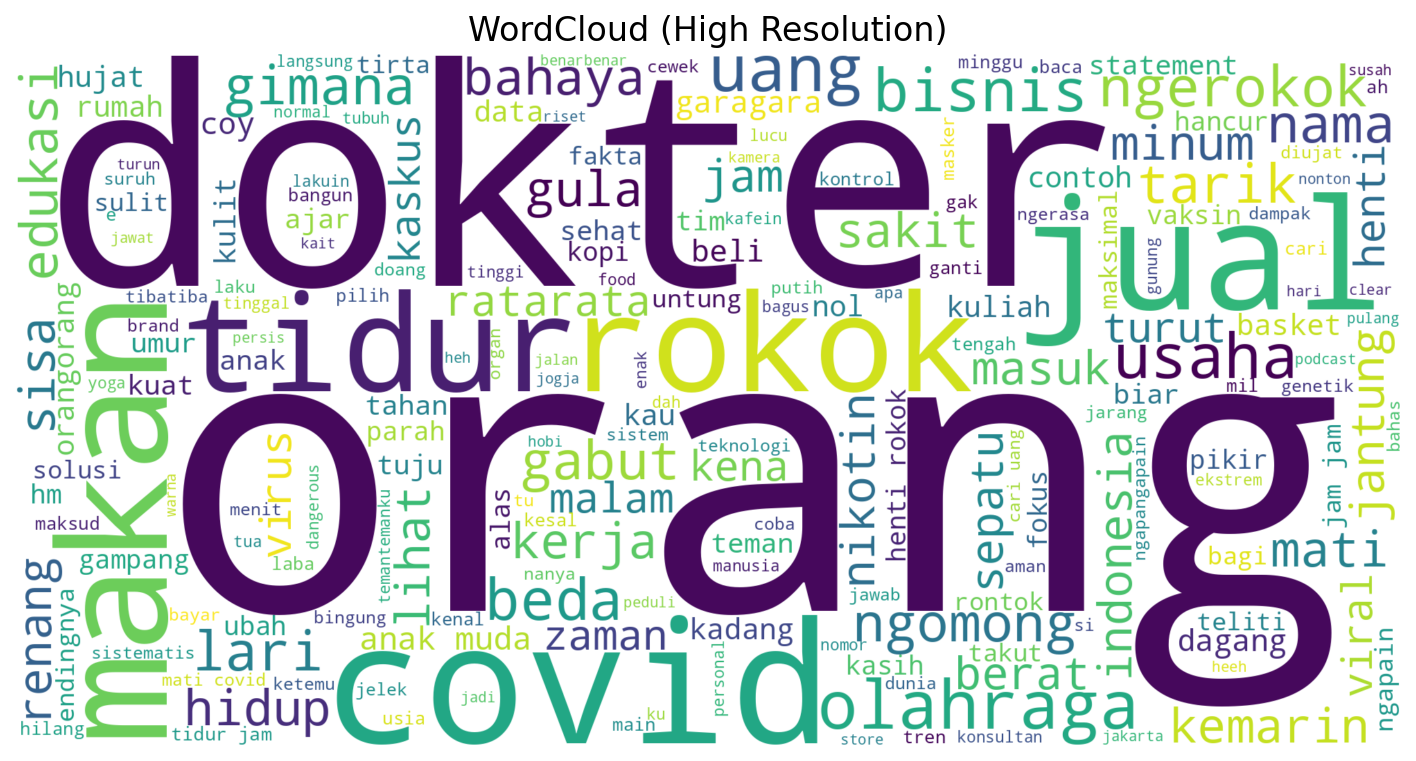

In [48]:
# ==============================
# 6. REPRESENTASI DOKUMEN (BoW)
# ==============================

from gensim import corpora
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

# 🔹 6.1 Membuat Dictionary
dictionary = corpora.Dictionary(documents)

print("Jumlah kata unik:", len(dictionary))

# 🔹 6.2 Filter kata
dictionary.filter_extremes(
    no_below=3,
    no_above=0.35
)

print("Jumlah kata setelah filtering:", len(dictionary))

# 🔹 6.3 Membuat Corpus (BoW)
corpus = [dictionary.doc2bow(doc) for doc in documents]

# ==============================
# CONTOH HASIL
# ==============================

print("\nContoh BoW dokumen pertama (ID, freq):")
print(corpus[0])

print("\nVersi dengan kata asli:")
for word_id, freq in corpus[0]:
    print(f"{dictionary[word_id]} : {freq}")

# ==============================
# VISUALISASI BAG OF WORDS
# ==============================

# 🔹 Gabungkan semua kata
all_words = [word for doc in documents for word in doc]

# 🔹 Hitung frekuensi
word_freq = Counter(all_words)

# 🔹 Ambil top 20 kata
top_n = 20
common_words = word_freq.most_common(top_n)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

# 🔹 BAR CHART
plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Kata Terbanyak (Bag of Words)")
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# ==============================
# WORDCLOUD (OPSIONAL)
# ==============================

text = " ".join(all_words)

# 🔹 Tambahan stopwords (opsional, biar lebih bersih)
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["yang", "dan", "di", "ke", "dari"])  # sesuaikan

# 🔹 Generate WordCloud HD
wordcloud = WordCloud(
    width=2000,               # resolusi lebar
    height=1000,              # resolusi tinggi
    background_color='white', # background putih
    colormap='viridis',       # warna menarik (bisa: plasma, inferno, magma)
    max_words=200,
    stopwords=custom_stopwords,
    contour_width=1,
    contour_color='black'
).generate(text)

# 🔹 Plot dengan kualitas tinggi
plt.figure(figsize=(12, 6), dpi=150)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud (High Resolution)", fontsize=16)
plt.show()

K: 2 | Coherence: 0.2223 | Perplexity: -5.8358
K: 3 | Coherence: 0.2567 | Perplexity: -5.8262
K: 4 | Coherence: 0.4320 | Perplexity: -5.8113
K: 5 | Coherence: 0.3177 | Perplexity: -5.8845
K: 6 | Coherence: 0.3475 | Perplexity: -5.8690
K: 7 | Coherence: 0.3438 | Perplexity: -5.8632
K: 8 | Coherence: 0.4101 | Perplexity: -5.8596
K: 9 | Coherence: 0.3886 | Perplexity: -5.9104
K: 10 | Coherence: 0.4277 | Perplexity: -5.8840
K: 11 | Coherence: 0.4447 | Perplexity: -5.9134
K: 12 | Coherence: 0.4502 | Perplexity: -5.9093
K: 13 | Coherence: 0.4964 | Perplexity: -5.9344
K: 14 | Coherence: 0.4381 | Perplexity: -5.9446


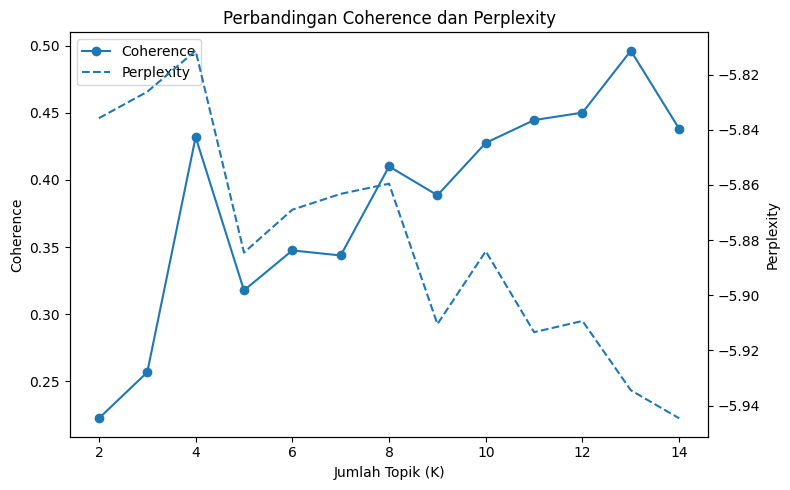


Best K berdasarkan coherence: 13
Best K berdasarkan perplexity: 14


In [49]:
# ==============================
# 7. PENENTUAN JUMLAH TOPIK
# ==============================

topic_range = range(2, 15)

coherence_values = []
perplexity_values = []
models = []

for k in topic_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10
    )

    # ===== COHERENCE =====
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=documents,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = coherence_model.get_coherence()

    # ===== PERPLEXITY =====
    perplexity = lda_model.log_perplexity(corpus)

    # simpan
    coherence_values.append(coherence)
    perplexity_values.append(perplexity)
    models.append(lda_model)

    print(f"K: {k} | Coherence: {coherence:.4f} | Perplexity: {perplexity:.4f}")

# ==============================
# VISUALISASI (FIX + LABEL)
# ==============================

fig, ax1 = plt.subplots(figsize=(8,5))

# Coherence (kiri)
line1 = ax1.plot(
    topic_range,
    coherence_values,
    marker='o',
    label='Coherence',
)
ax1.set_xlabel("Jumlah Topik (K)")
ax1.set_ylabel("Coherence")

# Perplexity (kanan)
ax2 = ax1.twinx()
line2 = ax2.plot(
    topic_range,
    perplexity_values,
    linestyle='--',
    label='Perplexity'
)
ax2.set_ylabel("Perplexity")

# ==============================
# LEGEND (gabung dua axis)
# ==============================
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc='best')

plt.title("Perbandingan Coherence dan Perplexity")
plt.tight_layout()
plt.show()

# ==============================
# PILIH MODEL (3 PENDEKATAN)
# ==============================

# 1. BEST COHERENCE
best_coh_index = coherence_values.index(max(coherence_values))
best_k_coh = topic_range[best_coh_index]

# 2. BEST PERPLEXITY (paling kecil)
best_perp_index = perplexity_values.index(min(perplexity_values))
best_k_perp = topic_range[best_perp_index]

print("\nBest K berdasarkan coherence:", best_k_coh)
print("Best K berdasarkan perplexity:", best_k_perp)

In [50]:
# ==============================
# 3. TRIAL & ERROR (MANUAL)
# ==============================

chosen_k = 9

chosen_index = list(topic_range).index(chosen_k)
best_model = models[chosen_index]

print("Best K final (manual/trial & error):", chosen_k)

Best K final (manual/trial & error): 9


In [51]:
# ==============================
# 8. TOPIC MODELLING (LDA)
# ==============================

num_topics = chosen_k

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=15,
    alpha='auto',
    per_word_topics=True
)

In [52]:
# ==============================
# 9. TOPIC-WORD DISTRIBUTION
# ==============================

print("\nTopik dan kata-katanya:\n")

for i, topic in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"Topik {i}:")
    print(topic)
    print()


Topik dan kata-katanya:

Topik 0:
0.051*"gula" + 0.034*"malam" + 0.030*"ngomong" + 0.028*"minum" + 0.026*"gabut" + 0.023*"muda" + 0.020*"kopi" + 0.019*"indonesia" + 0.016*"manis" + 0.015*"anak"

Topik 1:
0.039*"anak" + 0.029*"jual" + 0.029*"lari" + 0.026*"kaskus" + 0.025*"olahraga" + 0.020*"kuliah" + 0.018*"hidup" + 0.018*"basket" + 0.018*"dagang" + 0.017*"kuat"

Topik 2:
0.038*"covid" + 0.018*"usaha" + 0.017*"bisnis" + 0.015*"cari" + 0.015*"tarik" + 0.015*"gabut" + 0.015*"anak" + 0.015*"masuk" + 0.014*"lihat" + 0.013*"ratarata"

Topik 3:
0.090*"renang" + 0.047*"olahraga" + 0.034*"kulit" + 0.029*"gula" + 0.028*"resiko" + 0.023*"indonesia" + 0.021*"pakai" + 0.017*"umur" + 0.016*"turut" + 0.015*"lihat"

Topik 4:
0.041*"mati" + 0.032*"edukasi" + 0.030*"hujat" + 0.026*"covid" + 0.023*"virus" + 0.021*"diujat" + 0.021*"garagara" + 0.018*"kena" + 0.018*"sistematis" + 0.018*"masker"

Topik 5:
0.062*"sepatu" + 0.041*"jual" + 0.022*"alas" + 0.019*"nama" + 0.018*"dagang" + 0.018*"beli" + 0.018*"

In [53]:
# ==============================
# 10. DOCUMENT-TOPIC DISTRIBUTION
# ==============================

print("\nDistribusi topik untuk dokumen pertama:\n")

doc_topics = lda_model.get_document_topics(corpus[0])

for topic_id, prob in doc_topics:
    print(f"Topik {topic_id}: {prob:.4f}")


Distribusi topik untuk dokumen pertama:

Topik 6: 0.9947


In [54]:
# ==============================
# 11. ASSIGN TOPIK KE DOKUMEN
# ==============================

doc_dominant_topics = []

for i, doc in enumerate(corpus):
    topics = lda_model.get_document_topics(doc)

    # ambil topik dengan probabilitas tertinggi
    dominant_topic = max(topics, key=lambda x: x[1])

    doc_dominant_topics.append({
        "doc_id": i,
        "dominant_topic": dominant_topic[0],
        "probability": dominant_topic[1]
    })

# tampilkan 10 dokumen pertama
for d in doc_dominant_topics[:10]:
    print(f"Dokumen {d['doc_id']} → Topik {d['dominant_topic']} ({d['probability']:.3f})")

Dokumen 0 → Topik 6 (0.995)
Dokumen 1 → Topik 1 (0.994)
Dokumen 2 → Topik 8 (0.994)
Dokumen 3 → Topik 1 (0.995)
Dokumen 4 → Topik 5 (0.995)
Dokumen 5 → Topik 2 (0.995)
Dokumen 6 → Topik 2 (0.588)
Dokumen 7 → Topik 2 (0.996)
Dokumen 8 → Topik 2 (0.996)
Dokumen 9 → Topik 1 (0.943)


In [55]:
# fungsi ambil kata dari topik
def get_topic_words(topic_id):
    return [word for word, prob in lda_model.show_topic(topic_id, topn=5)]

# tampilkan dengan kata
for d in doc_dominant_topics[:10]:
    words = get_topic_words(d["dominant_topic"])
    print(f"Dokumen {d['doc_id']} → Topik {d['dominant_topic']} ({d['probability']:.3f})")
    print("Kata topik:", words)
    print()

df_topics = pd.DataFrame(doc_dominant_topics)
print(df_topics.head())

Dokumen 0 → Topik 6 (0.995)
Kata topik: ['tidur', 'jam', 'bangun', 'covid', 'bagus']

Dokumen 1 → Topik 1 (0.994)
Kata topik: ['anak', 'jual', 'lari', 'kaskus', 'olahraga']

Dokumen 2 → Topik 8 (0.994)
Kata topik: ['jual', 'covid', 'virus', 'hilang', 'jaga']

Dokumen 3 → Topik 1 (0.995)
Kata topik: ['anak', 'jual', 'lari', 'kaskus', 'olahraga']

Dokumen 4 → Topik 5 (0.995)
Kata topik: ['sepatu', 'jual', 'alas', 'nama', 'dagang']

Dokumen 5 → Topik 2 (0.995)
Kata topik: ['covid', 'usaha', 'bisnis', 'cari', 'tarik']

Dokumen 6 → Topik 2 (0.588)
Kata topik: ['covid', 'usaha', 'bisnis', 'cari', 'tarik']

Dokumen 7 → Topik 2 (0.996)
Kata topik: ['covid', 'usaha', 'bisnis', 'cari', 'tarik']

Dokumen 8 → Topik 2 (0.996)
Kata topik: ['covid', 'usaha', 'bisnis', 'cari', 'tarik']

Dokumen 9 → Topik 1 (0.943)
Kata topik: ['anak', 'jual', 'lari', 'kaskus', 'olahraga']

   doc_id  dominant_topic  probability
0       0               6     0.994713
1       1               1     0.994389
2       2    

In [56]:
# ==============================
# 12. LABELING TOPIK
# ==============================

topic_labels = {}

for i in range(num_topics):
    words = [word for word, prob in lda_model.show_topic(i, topn=10)]

    print(f"Topik {i}:")
    print(words)

    # kamu isi label manual di sini
    label = input(f"Masukkan label untuk Topik {i}: ")

    topic_labels[i] = label
    print()

Topik 0:
['gula', 'malam', 'ngomong', 'minum', 'gabut', 'muda', 'kopi', 'indonesia', 'manis', 'anak']
Masukkan label untuk Topik 0: Pola Konsumsi Minuman Manis dan Gaya Hidup Anak Muda

Topik 1:
['anak', 'jual', 'lari', 'kaskus', 'olahraga', 'kuliah', 'hidup', 'basket', 'dagang', 'kuat']
Masukkan label untuk Topik 1: Kehidupan Anak Muda: Olahraga dan Aktivitas Ekonomi

Topik 2:
['covid', 'usaha', 'bisnis', 'cari', 'tarik', 'gabut', 'anak', 'masuk', 'lihat', 'ratarata']
Masukkan label untuk Topik 2: Dampak COVID terhadap aktivitas ekonomi dan usaha masyarakat

Topik 3:
['renang', 'olahraga', 'kulit', 'gula', 'resiko', 'indonesia', 'pakai', 'umur', 'turut', 'lihat']
Masukkan label untuk Topik 3: Gaya Hidup Sehat dan Risiko Penyakit

Topik 4:
['mati', 'edukasi', 'hujat', 'covid', 'virus', 'diujat', 'garagara', 'kena', 'sistematis', 'masker']
Masukkan label untuk Topik 4: Pandemi COVID-19 dan Respons Sosial Masyarakat

Topik 5:
['sepatu', 'jual', 'alas', 'nama', 'dagang', 'beli', 'menit', 

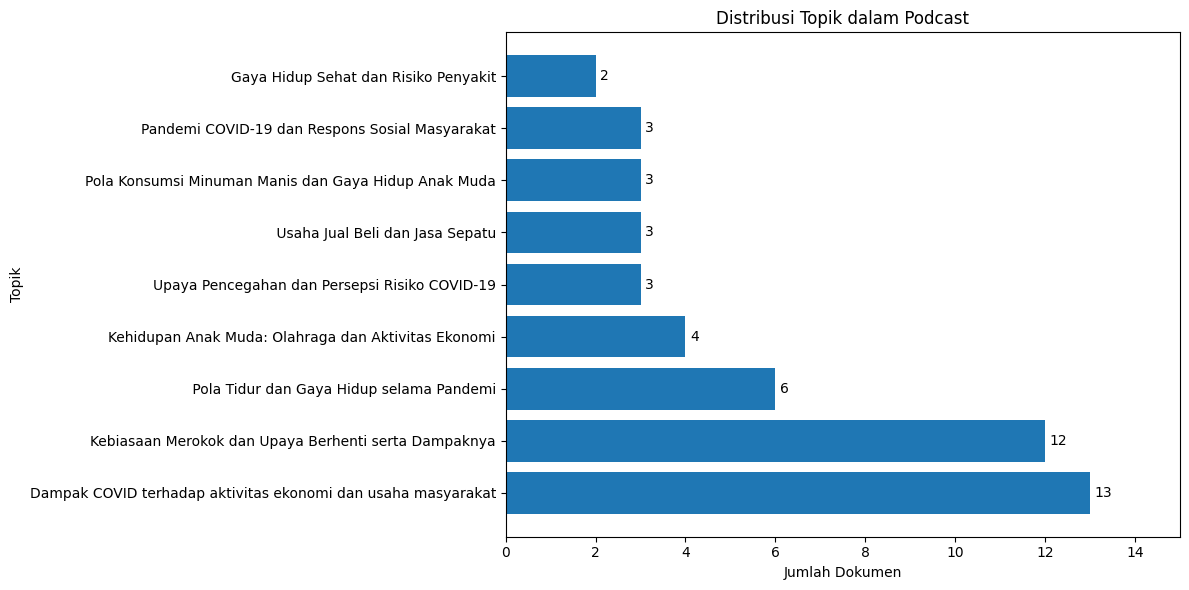

In [57]:
# ==============================
# HITUNG DISTRIBUSI
# ==============================
topic_counts = Counter([d["dominant_topic"] for d in doc_dominant_topics])

# ==============================
# VISUALISASI
# ==============================
sorted_topics = sorted(topic_counts.items(), key=lambda x: x[1], reverse=True)

topics = [int(t[0]) for t in sorted_topics]
counts = [t[1] for t in sorted_topics]
labels = [topic_labels.get(t, f"Topik {t}") for t in topics]

plt.figure(figsize=(12, 6))

bars = plt.barh(labels, counts)

plt.xlim(0, max(counts) + 2)

plt.xlabel("Jumlah Dokumen")
plt.ylabel("Topik")
plt.title("Distribusi Topik dalam Podcast")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center')

plt.tight_layout()
plt.show()

In [58]:
# ==============================
# 14. RINGKASAN ANALISIS
# ==============================

total_docs = len(doc_dominant_topics)

print("\nRingkasan Analisis:\n")

for topic_id, count in topic_counts.items():
    label = topic_labels[topic_id]
    percentage = (count / total_docs) * 100

    print(f"{label}: {count} dokumen ({percentage:.2f}%)")


Ringkasan Analisis:

 Pola Tidur dan Gaya Hidup selama Pandemi: 6 dokumen (12.24%)
Kehidupan Anak Muda: Olahraga dan Aktivitas Ekonomi: 4 dokumen (8.16%)
Upaya Pencegahan dan Persepsi Risiko COVID-19: 3 dokumen (6.12%)
 Usaha Jual Beli dan Jasa Sepatu: 3 dokumen (6.12%)
Dampak COVID terhadap aktivitas ekonomi dan usaha masyarakat: 13 dokumen (26.53%)
Pola Konsumsi Minuman Manis dan Gaya Hidup Anak Muda: 3 dokumen (6.12%)
Pandemi COVID-19 dan Respons Sosial Masyarakat: 3 dokumen (6.12%)
Kebiasaan Merokok dan Upaya Berhenti serta Dampaknya: 12 dokumen (24.49%)
Gaya Hidup Sehat dan Risiko Penyakit: 2 dokumen (4.08%)
